# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

In [1]:
# For data manipulation
import pandas as pd
import numpy as np
from scipy.signal import argrelextrema

# For plotting
import mplfinance as mpf

import warnings 
warnings.filterwarnings('ignore')

# Helper functions
import sys
sys.path.append('..')
from data_modules.price_action_util_quantra import *

<a id='data'></a>
## Read the Data

Import the file `spy_daily_1993_2018.csv` using the `read_csv` method of `pandas`. This file has the OHLCV values for the SPY ETF of the daily frequency. This CSV file is available in the zip file of the unit 'Python Codes and Data' in the 'Course Summary' section.

In [2]:
# Import the stock price data
data = pd.read_csv(
    '../data_modules/spy_daily_1993_2018.csv', index_col=0)

# Change the index type to datetime
data.index = pd.to_datetime(data.index)

# Display the data
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
1993-01-29,25.352047,25.352047,25.225917,25.334028,1003200
1993-02-01,25.352036,25.514202,25.352036,25.514202,480500
1993-02-02,25.496201,25.586294,25.442146,25.568275,201300
1993-02-03,25.604306,25.856565,25.586288,25.838547,529400
1993-02-04,25.928646,26.000720,25.640350,25.946665,531500


## Min-Max

In [3]:
# Fetch dataframes of minima and maxima values
minima_prices, maxima_prices = get_min_max(data, 3)

# Store values of both minima and maxima points in a sequential order
min_max = pd.concat([minima_prices, maxima_prices]).sort_index()

## Head and Shoudlers

In [4]:
# HS
# Detect head and shoulders patterns and store the results
hs_patterns = hs_scanner(min_max, minima_prices, maxima_prices)

# Initialise the dataframe and specify column names
hs_patterns_data = pd.DataFrame(hs_patterns)
hs_patterns_data.columns = ['sh1_date', 'neck1_date',
                            'head_date', 'neck2_date', 'sh2_date']

# Populate the dataframe with relevant values
hs_patterns_data['sh1_price'] = data.loc[hs_patterns_data.sh1_date, 'High'].values
hs_patterns_data['neck1_price'] = data.loc[hs_patterns_data.neck1_date, 'Low'].values
hs_patterns_data['head_price'] = data.loc[hs_patterns_data.head_date, 'High'].values
hs_patterns_data['neck2_price'] = data.loc[hs_patterns_data.neck2_date, 'Low'].values
hs_patterns_data['sh2_price'] = data.loc[hs_patterns_data.sh2_date, 'High'].values

# Function to fetch pattern confirmation date


def get_confirmation_date_hs(hs_patterns, data=data):

    # Initialise data after the formation of shoulder2
    data_after_sh2 = data.loc[hs_patterns.sh2_date:].Close
    try:
        # Capture the date if prices were able to close below the neckline
        return data_after_sh2[data_after_sh2 < hs_patterns.neck2_price].index[0]
    except:
        # Assign NaN if prices were not able to close below the neckline
        return np.nan


# Store the information for confirmation with the rest of the pattern data
hs_patterns_data['confirmation_date'] = hs_patterns_data.apply(
    get_confirmation_date_hs, axis=1)
# Drop NaN values from 'hs_patterns_data'
hs_patterns_data.dropna(inplace=True)

# Store the number of days taken to generate a short entry date in the column 'time_for_confirmation'
hs_patterns_data['time_for_confirmation'] = (
    hs_patterns_data.confirmation_date - hs_patterns_data.sh2_date).dt.days

# Selecting the patterns that generated short entry within 30 days of forming the right shoulder
hs_patterns_data = hs_patterns_data[(hs_patterns_data['time_for_confirmation'] >5) & (hs_patterns_data['time_for_confirmation'] < 30)]
hs_patterns_data['signal'] = -1

# Set stop-loss 1% above the right shoulder
hs_patterns_data['stoploss'] = hs_patterns_data['sh2_price']*1.01

# Calculate the distance between the head and the neckline
hs_patterns_data['head_length'] = hs_patterns_data['head_price'] - \
    hs_patterns_data['neck2_price']

# Set target at a distance of head_length below the neckline
hs_patterns_data['target'] = hs_patterns_data['neck2_price'] - \
    1 * hs_patterns_data['head_length']

# Set the columns containing dates to datetime format
hs_patterns_data[['sh1_date', 'neck1_date', 'head_date', 'neck2_date', 'sh2_date']] = hs_patterns_data[[
    'sh1_date', 'neck1_date', 'head_date', 'neck2_date', 'sh2_date']].apply(pd.to_datetime, format='%Y-%m-%d')

# Convert the confirmation_date column type to datetime
hs_patterns_data.confirmation_date = pd.to_datetime(
    hs_patterns_data.confirmation_date)

# Set the index of pattern_details as 'confirmation_date' column
hs_patterns_data.index = hs_patterns_data.confirmation_date


# Merge the 'pattern_details' dataframe with the dataframe 'data'
hs_strategy_data = pd.merge(data, hs_patterns_data,
                            left_index=True, right_index=True, how='left')
hs_strategy_data.signal.fillna(0, inplace=True)

hs_trade_details = backtester(hs_strategy_data)
hs_trade_details['returns'] = 100*(hs_trade_details.entry_price -
                                   hs_trade_details.exit_price)/hs_trade_details.exit_price

Trade No: 1 | Entry Date: 1993-04-02 00:00:00 | Entry Price: 25.54 | Position: -1.0
Exit Type: TP | Exit Date: 1993-04-26 00:00:00 | Exit Price: 25.15 | PnL: 0.39 | Cum PnL: 0.39
------------------------------
Trade No: 2 | Entry Date: 1994-11-21 00:00:00 | Entry Price: 27.69 | Position: -1.0
Exit Type: TP | Exit Date: 1994-12-08 00:00:00 | Exit Price: 27.02 | PnL: 0.67 | Cum PnL: 1.06
------------------------------
Trade No: 3 | Entry Date: 1998-05-29 00:00:00 | Entry Price: 70.31 | Position: -1.0
Exit Type: SL | Exit Date: 1998-06-26 00:00:00 | Exit Price: 73.54 | PnL: -3.23 | Cum PnL: -2.17
------------------------------
Trade No: 4 | Entry Date: 2001-06-13 00:00:00 | Entry Price: 83.25 | Position: -1.0
Exit Type: TP | Exit Date: 2001-08-17 00:00:00 | Exit Price: 78.1 | PnL: 5.15 | Cum PnL: 2.98
------------------------------
Trade No: 5 | Entry Date: 2006-02-07 00:00:00 | Entry Price: 90.53 | Position: -1.0
Exit Type: SL | Exit Date: 2006-03-14 00:00:00 | Exit Price: 93.92 | PnL: -

## Inverse Head and Shoulders

In [5]:
# IHS
# Detect inverse head and shoulders patterns and store the results
ihs_patterns = ihs_scanner(min_max, minima_prices, maxima_prices)

# Initialise the dataframe and specify column names
ihs_patterns_data = pd.DataFrame(ihs_patterns)
ihs_patterns_data.columns = ['sh1_date', 'neck1_date',
                             'head_date', 'neck2_date', 'sh2_date']

# Populate the dataframe with relevant values
ihs_patterns_data['sh1_price'] = data.loc[ihs_patterns_data.sh1_date, 'Low'].values
ihs_patterns_data['neck1_price'] = data.loc[ihs_patterns_data.neck1_date, 'High'].values
ihs_patterns_data['head_price'] = data.loc[ihs_patterns_data.head_date, 'Low'].values
ihs_patterns_data['neck2_price'] = data.loc[ihs_patterns_data.neck2_date, 'High'].values
ihs_patterns_data['sh2_price'] = data.loc[ihs_patterns_data.sh2_date, 'Low'].values

# Function to calculate the long entry date of the inverse head and shoulders pattern


def get_confirmation_date_ihs(ihs_patterns, data=data):

    # store the data after second shoulder in 'data_after_sh2'
    data_after_sh2 = data.loc[ihs_patterns.sh2_date:]['Close']

    try:
        # return the long entry date if price went above the second shoulder price
        return data_after_sh2[data_after_sh2 > ihs_patterns.neck2_price].index[0]

    except:
        # return nan if price never went above the second shoulder price
        return np.nan


# Create the column 'confirmation_date' to store the long entry dates calculated using the function get_confirmation_date()
ihs_patterns_data['confirmation_date'] = ihs_patterns_data.apply(
    get_confirmation_date_ihs, axis=1)

# Drop NaN values from 'ihs_patterns_data'
ihs_patterns_data.dropna(inplace=True)

# Store the number of days taken to generate long entry date in the column 'time_for_confirmation'
ihs_patterns_data['time_for_confirmation'] = (
    ihs_patterns_data.confirmation_date - ihs_patterns_data.sh2_date).dt.days

# Selecting the patterns that generated long entry within 30 days of forming the right shoulder
ihs_patterns_data = ihs_patterns_data[(ihs_patterns_data['time_for_confirmation'] > 5) & (ihs_patterns_data['time_for_confirmation'] < 30)]

# Create'signal' column with values as '1' since we are buying once the pattern is confirmed
ihs_patterns_data['signal'] = 1

# Stop-loss 1% below right shoulder
ihs_patterns_data['stoploss'] = ihs_patterns_data['sh2_price']*0.99

# Calculate the head length and store it in the column 'head_length'
ihs_patterns_data['head_length'] = ihs_patterns_data['neck2_price'] - \
    ihs_patterns_data['head_price']

# Calculate profit target and store it in the column 'target'
ihs_patterns_data['target'] = ihs_patterns_data['neck2_price'] + \
    1 * ihs_patterns_data['head_length']
# Convert the confirmation_date column type to datetime
ihs_patterns_data.confirmation_date = pd.to_datetime(
    ihs_patterns_data.confirmation_date)

# Convert the index of pattern_details to 'confirmation_date' column
ihs_patterns_data.index = ihs_patterns_data.confirmation_date
# Merge the 'pattern_details' dataframe with the dataframe 'data'
ihs_strategy_data = pd.merge(data, ihs_patterns_data,
                             left_index=True, right_index=True, how='left')
ihs_strategy_data.signal.fillna(0, inplace=True)

ihs_trade_details = backtester(ihs_strategy_data)
ihs_trade_details['returns'] = 100*(ihs_trade_details.entry_price -
                                    ihs_trade_details.exit_price)/ihs_trade_details.exit_price

Trade No: 1 | Entry Date: 1993-06-28 00:00:00 | Entry Price: 26.42 | Position: 1.0
Exit Type: TP | Exit Date: 1993-08-16 00:00:00 | Exit Price: 26.47 | PnL: 0.05 | Cum PnL: 0.05
------------------------------
Trade No: 2 | Entry Date: 1993-09-27 00:00:00 | Entry Price: 27.17 | Position: 1.0
Exit Type: TP | Exit Date: 1993-12-27 00:00:00 | Exit Price: 27.78 | PnL: 0.61 | Cum PnL: 0.66
------------------------------
Trade No: 3 | Entry Date: 1995-09-01 00:00:00 | Entry Price: 34.77 | Position: 1.0
Exit Type: TP | Exit Date: 1995-09-12 00:00:00 | Exit Price: 35.58 | PnL: 0.81 | Cum PnL: 1.47
------------------------------
Trade No: 4 | Entry Date: 1995-11-03 00:00:00 | Entry Price: 36.55 | Position: 1.0
Exit Type: TP | Exit Date: 1995-12-04 00:00:00 | Exit Price: 38.09 | PnL: 1.54 | Cum PnL: 3.01
------------------------------
Trade No: 5 | Entry Date: 1997-01-14 00:00:00 | Entry Price: 48.74 | Position: 1.0
Exit Type: TP | Exit Date: 1997-02-13 00:00:00 | Exit Price: 51.53 | PnL: 2.79 | 

## Box Plot

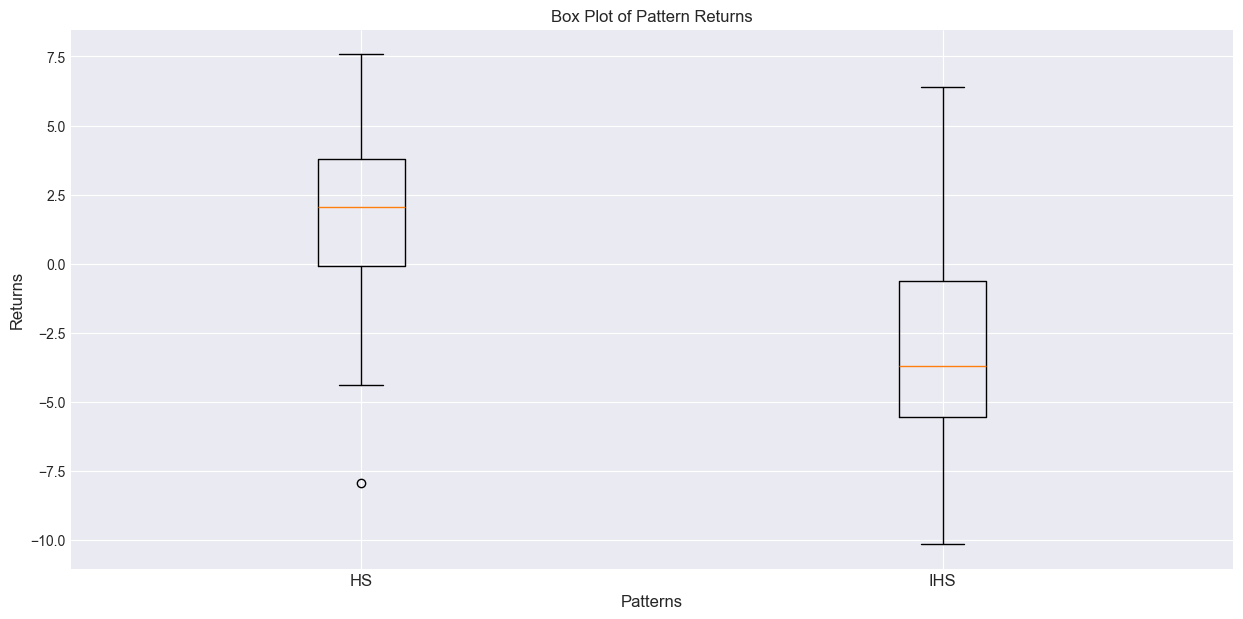

In [6]:
# figure related code
fig = plt.figure(figsize=(15, 7))
ax = fig.add_subplot(111)
ax.boxplot([hs_trade_details.returns, ihs_trade_details.returns])
ax.set_title('Box Plot of Pattern Returns')
ax.set_xlabel('Patterns', fontsize=12)
ax.set_ylabel('Returns', fontsize=12)
ax.set_xticklabels(['HS', 'IHS'], fontsize=12)
plt.show()